In [1]:
import os
import netCDF4 as netcdf
import numpy as np
import sys
maindir = os.getcwd()
sys.path.append(maindir+"/src")

PATH = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP/Training-Ext/Amon/pr'

In [2]:
DIR_LIST = os.listdir(PATH)

dic_data = {}
dic_forced_response = {}

# how to center the data with respect to the monthly mean

# 1. calculate the monthly mean
# 2. subtract the monthly mean from the data
# 3. calculate the forced response by averaging over the time dimension

for idx_m, dir in enumerate(DIR_LIST):

    print(f'Processing {idx_m+1}/{len(DIR_LIST)}: {dir}')
    dir_path = os.path.join(PATH, dir)
    file_list = os.listdir(dir_path)

    dic_data[dir] = np.zeros((len(file_list), 2652, 72, 144), dtype=np.float32)
    dic_forced_response[dir] = np.zeros((len(file_list), 2652, 72, 144), dtype=np.float32)

    for idx_f, file in enumerate(file_list):
        print(f'  Processing {idx_f+1}/{len(file_list)}: {file}')
        file_path = os.path.join(dir_path, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'][:])
        longitude = np.array(netcdf_file.variables['lon'][:])
        latitude = np.array(netcdf_file.variables['lat'][:])
        dic_data[dir][idx_f,:,:,:] = np.array(netcdf_file.variables['pr']) 
        for i in range(12):
            dic_data[dir][idx_f,np.arange(time.shape[0]) % 12 == i,:,:] = dic_data[dir][idx_f,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(dic_data[dir][idx_f, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

        # print(f'  Tas shape: {tas.shape}')
    dic_forced_response[dir][:,:,:,:] = np.nanmean(dic_data[dir], axis=0)
    

Processing 1/5: CESM2
  Processing 1/50: pr_mon_CESM2_historical_ssp370_r1251.013i1p1f1.188001-210012.nc
  Processing 2/50: pr_mon_CESM2_historical_ssp370_r1011.001i1p1f1.188001-210012.nc
  Processing 3/50: pr_mon_CESM2_historical_ssp370_r1251.015i1p1f1.188001-210012.nc
  Processing 4/50: pr_mon_CESM2_historical_ssp370_r1031.002i1p1f1.188001-210012.nc
  Processing 5/50: pr_mon_CESM2_historical_ssp370_r1251.014i1p1f1.188001-210012.nc
  Processing 6/50: pr_mon_CESM2_historical_ssp370_r1051.003i1p1f1.188001-210012.nc
  Processing 7/50: pr_mon_CESM2_historical_ssp370_r1251.016i1p1f1.188001-210012.nc
  Processing 8/50: pr_mon_CESM2_historical_ssp370_r1071.004i1p1f1.188001-210012.nc
  Processing 9/50: pr_mon_CESM2_historical_ssp370_r1251.017i1p1f1.188001-210012.nc
  Processing 10/50: pr_mon_CESM2_historical_ssp370_r1091.005i1p1f1.188001-210012.nc
  Processing 11/50: pr_mon_CESM2_historical_ssp370_r1251.018i1p1f1.188001-210012.nc
  Processing 12/50: pr_mon_CESM2_historical_ssp370_r1111.006i1p

In [26]:
# read the test data
PATH_EVAL = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/Evaluation-Tier1/'


DIR_LIST_TEST = os.listdir(PATH_EVAL)
data_test = np.zeros((10, 876, 72, 144), dtype=np.float32)


lst_test_name = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']

for idx_r, file in enumerate(DIR_LIST_TEST):

    if file.startswith('pr_') and file.endswith('.nc'):
        print(f'  Processing {idx_r+1}/{len(DIR_LIST_TEST)}: {file}')
        file_path = os.path.join(PATH_EVAL, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'])
        longitude = np.array(netcdf_file.variables['lon'])
        latitude = np.array(netcdf_file.variables['lat'])
        if file[8] in lst_test_name:
            # find position of file[9] in lst_test_name
            idx_test = lst_test_name.index(file[8])
            print(f'  Found test data for {file[8]} at index {idx_test}')
            data_test[idx_test,:,:,:] = np.array(netcdf_file.variables['pr']) 

            for i in range(12):
                data_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] = data_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_test[idx_test, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)


  Processing 2/81: pr_mon_1E.195001-202212.nc
  Found test data for E at index 4
  Processing 4/81: pr_mon_1F.195001-202212.nc
  Found test data for F at index 5
  Processing 14/81: pr_mon_1H.195001-202212.nc
  Found test data for H at index 7
  Processing 19/81: pr_mon_1C.195001-202212.nc
  Found test data for C at index 2
  Processing 20/81: pr_mon_1G.195001-202212.nc
  Found test data for G at index 6
  Processing 43/81: pr_mon_1D.195001-202212.nc
  Found test data for D at index 3
  Processing 47/81: pr_mon_1A.195001-202212.nc
  Found test data for A at index 0
  Processing 54/81: pr_mon_1J.195001-202212.nc
  Found test data for J at index 9
  Processing 70/81: pr_mon_1I.195001-202212.nc
  Found test data for I at index 8
  Processing 75/81: pr_mon_1B.195001-202212.nc
  Found test data for B at index 1


In [27]:
# Read the ground truth data
PATH_GROUND_TRUTH = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/ensmeans-Tier1'

DIR_LIST_GROUND_TRUTH = os.listdir(PATH_GROUND_TRUTH)

data_ground_truth_test = np.zeros((10, 876, 72, 144), dtype=np.float32)


for idx_r, file in enumerate(DIR_LIST_GROUND_TRUTH):

    if file.__contains__('.pr.'):
        
        print(f'  Processing {idx_r+1}: {file}')

        # read the ground truth data
        file_path = os.path.join(PATH_GROUND_TRUTH, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'][:])
        longitude = np.array(netcdf_file.variables['lon'][:])
        latitude = np.array(netcdf_file.variables['lat'][:])
        if file[1] in lst_test_name:
            # find position of file[1] in lst_test_name
            idx_test = lst_test_name.index(file[1])
            print(f'  Found test data for {file[1]} at index {idx_test}')
            data_ground_truth_test[idx_test,:,:,:] = np.array(netcdf_file.variables['arr_EM'])

            for i in range(12):
                data_ground_truth_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] = data_ground_truth_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_ground_truth_test[idx_test, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

            print(f'  Tas shape: {data_ground_truth_test[idx_test,:,:,:].shape}')

  Processing 5: 1A.pr.EM.1950-2022.nc
  Found test data for A at index 0
  Tas shape: (876, 72, 144)
  Processing 13: 1B.pr.EM.1950-2022.nc
  Found test data for B at index 1
  Tas shape: (876, 72, 144)
  Processing 21: 1C.pr.EM.1950-2022.nc
  Found test data for C at index 2
  Tas shape: (876, 72, 144)
  Processing 29: 1D.pr.EM.1950-2022.nc
  Found test data for D at index 3
  Tas shape: (876, 72, 144)
  Processing 37: 1E.pr.EM.1950-2022.nc
  Found test data for E at index 4
  Tas shape: (876, 72, 144)
  Processing 45: 1F.pr.EM.1950-2022.nc
  Found test data for F at index 5
  Tas shape: (876, 72, 144)
  Processing 53: 1G.pr.EM.1950-2022.nc
  Found test data for G at index 6
  Tas shape: (876, 72, 144)
  Processing 61: 1H.pr.EM.1950-2022.nc
  Found test data for H at index 7
  Tas shape: (876, 72, 144)
  Processing 69: 1J.pr.EM.1950-2022.nc
  Found test data for J at index 9
  Tas shape: (876, 72, 144)


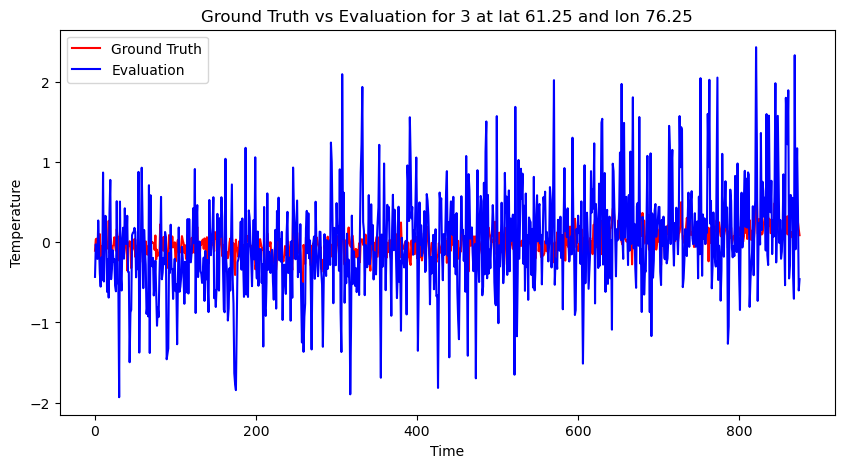

In [30]:
# check if the data is correct by plotting the ensemble mean and the evaluation data on the same plot
import matplotlib.pyplot as plt

idx_run = 3
idx_lat = 60
idx_lon = 30

x_tmp = data_ground_truth_test[idx_run,:,idx_lat,idx_lon]
y_tmp = data_test[idx_run,:,idx_lat,idx_lon]

plt.figure(figsize=(10, 5))
plt.plot(x_tmp, label='Ground Truth', color='red')
plt.plot(y_tmp, label='Evaluation', color='blue')
plt.title(f'Ground Truth vs Evaluation for {idx_run} at lat {latitude[idx_lat]} and lon {longitude[idx_lon]}')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.show()

In [31]:
# get the estimates of the other participants 

# Read the estimates of the other methods
PATH_TEST = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/ForceSMIP-estimates-Tier1'

DIR_LIST_TEST = os.listdir(PATH_TEST)
data_estimates = np.zeros((30,10, 876, 72, 144), dtype=np.float32)



count = 0
for idx_r, file in enumerate(DIR_LIST_TEST):

    if file.startswith('pr_'):

        # read the test data
        print(f'  Processing {idx_r+1}/{len(DIR_LIST_TEST)}: {file}')
        file_path = os.path.join(PATH_TEST, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')


        # set variables
        time = np.array(netcdf_file.variables['time'])
        longitude = np.array(netcdf_file.variables['lon'])
        latitude = np.array(netcdf_file.variables['lat'])

        if file[4] in lst_test_name:
            # find position of file[1] in lst_test_name
            idx_test = lst_test_name.index(file[4])
            print(f'  Found test data for {file[4]} at index {idx_test}')
            data_estimates[:,idx_test,:,:,:] = np.array(netcdf_file.variables['forced_component']) 

            print(f'  Tas shape: {data_estimates[:,idx_test,:,:,:].shape}')


# center the estimates of the other methods that are not centered yet
lst_to_center = [8,9,14,24]

# center the methods that are not centered
for idx_m in lst_to_center:
    print(f'Centering data for method {idx_m}')
    for i in range(12):
        for j in range(10):
            data_estimates[idx_m,j,np.arange(time.shape[0]) % 12 == i,:,:] = data_estimates[idx_m,j,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_estimates[idx_m,j, np.arange(time.shape[0]) % 12 == i,:,:], axis=0)



  Processing 31/80: pr_1A_1950_2022.nc
  Found test data for A at index 0
  Tas shape: (30, 876, 72, 144)
  Processing 32/80: pr_1B_1950_2022.nc
  Found test data for B at index 1
  Tas shape: (30, 876, 72, 144)
  Processing 33/80: pr_1C_1950_2022.nc
  Found test data for C at index 2
  Tas shape: (30, 876, 72, 144)
  Processing 34/80: pr_1D_1950_2022.nc
  Found test data for D at index 3
  Tas shape: (30, 876, 72, 144)
  Processing 35/80: pr_1E_1950_2022.nc
  Found test data for E at index 4
  Tas shape: (30, 876, 72, 144)
  Processing 36/80: pr_1F_1950_2022.nc
  Found test data for F at index 5
  Tas shape: (30, 876, 72, 144)
  Processing 37/80: pr_1G_1950_2022.nc
  Found test data for G at index 6
  Tas shape: (30, 876, 72, 144)
  Processing 38/80: pr_1H_1950_2022.nc
  Found test data for H at index 7
  Tas shape: (30, 876, 72, 144)
  Processing 39/80: pr_1I_1950_2022.nc
  Found test data for I at index 8
  Tas shape: (30, 876, 72, 144)
  Processing 40/80: pr_1J_1950_2022.nc
  Found

In [32]:
import torch

def normalize_data(data, means, vars):
    """Normalize the data with respect to the monthly mean and the variance of the anomaly.
       Args:
           data: numpy array of shape (runs, time steps, latitude, longitude)
           means: numpy array of shape (runs, latitude, longitude)
           vars: numpy array of shape (runs, latitude, longitude)
       Return:
           normalized_data: numpy array of shape (runs, time steps, latitude, longitude)
    """
    normalized_data = {}
    for idx,key in enumerate(data.keys()):
        normalized_data[key] = (data[key] - means[key]) / np.sqrt(vars[key])
    return normalized_data

def merge_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    
    for idx_m,m in enumerate(x.keys()):
        
        if idx_m ==0:

            x_train = torch.from_numpy(x[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0])/torch.sqrt(torch.tensor(x[m].shape[0]))
            y_train = torch.from_numpy(y[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0])/torch.sqrt(torch.tensor(x[m].shape[0]))


        else:
            x_train = torch.cat([x_train, torch.from_numpy(x[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0]) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)
            y_train = torch.cat([y_train, torch.from_numpy(y[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0]) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)

        print(f'  x_train shape: {x_train.shape}')
    return x_train, y_train


def reshape_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    x_train = {}
    y_train = {}
    
    for idx_m,m in enumerate(x.keys()):
        
        x_train[m] = torch.from_numpy(x[m]).to(torch.float32).reshape(x[m].shape[0],x[m].shape[1],longitude.shape[0]*latitude.shape[0])
        y_train[m] = torch.from_numpy(y[m]).to(torch.float32).reshape(x[m].shape[0],x[m].shape[1],longitude.shape[0]*latitude.shape[0])
        print(f'  x_train shape: {x_train[m].shape}')
        print(f'  y_train shape: {y_train[m].shape}')
    return x_train, y_train

In [33]:
def yearly_average(x, months_per_year=12):
    """
    Compute the yearly average of a time series.
    Args:
        data: numpy array of shape (time, ...)
        months_per_year: int, number of months in a year (default: 12)
    Returns:
        numpy array of shape (years, ...)
    """
    n_years = x.shape[1] // months_per_year
    data_reshaped = x.reshape(x.shape[0],n_years, months_per_year, x.shape[2],x.shape[3])
    return data_reshaped.mean(axis=2)


# Compute the yearly average for each key in the dictionary
def compute_yearly_average(data, months_per_year=12):
    """
    Compute the yearly average of a dictionary of numpy arrays.
    Args:
        data: dictionary of numpy arrays
        months_per_year: int, number of months in a year (default: 12)
    Returns:
        dictionary of numpy arrays with yearly averages
    """
    yearly_data = {}
    for key, m in enumerate(data.keys()):
        yearly_data[m] = yearly_average(data[m], months_per_year)

    return yearly_data

In [34]:
# Train the model on the yearly data
dic_data_yearly = compute_yearly_average(dic_data, months_per_year=12)
dic_forced_response_yearly = compute_yearly_average(dic_forced_response, months_per_year=12)

x_test_yearly = yearly_average(data_test, months_per_year=12)
y_test_yearly = yearly_average(data_ground_truth_test, months_per_year=12)

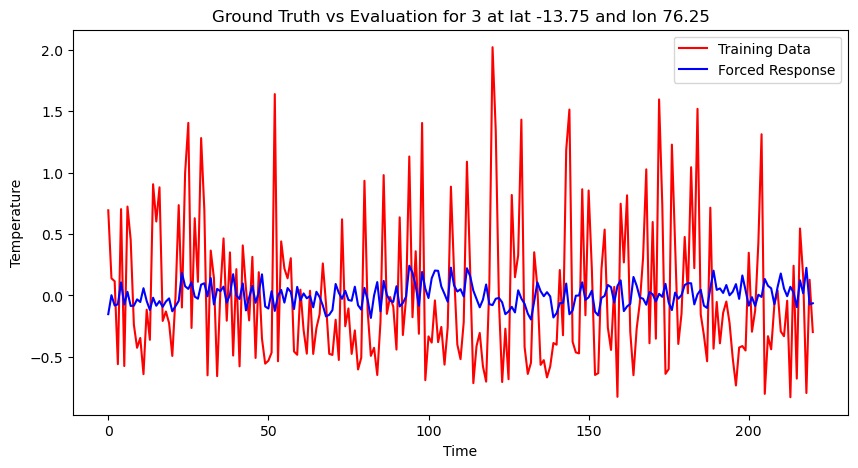

In [35]:
# plot time series in a single grid cell
idx_lat = 30
idx_lon = 30
plt.figure(figsize=(10, 5))
plt.plot(dic_data_yearly['CESM2'][0,:,idx_lat,idx_lon], label='Training Data', color='red')
plt.plot(dic_forced_response_yearly['CESM2'][0,:,idx_lat,idx_lon], label='Forced Response', color='blue')
plt.title(f'Ground Truth vs Evaluation for {idx_run} at lat {latitude[idx_lat]} and lon {longitude[idx_lon]}')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.show()

In [36]:
# compute the variance of anomaly per climate model and standardize
means_yearly = {}
vars_yearly = {}
vars = {}
means = {}

# for each model, compute the variance of the anomaly
for dir in DIR_LIST:
    print(f'Computing variance for {dir}')
    # means_yearly[dir] = np.nanmean(dic_data_yearly[dir], axis=0)
    means_yearly[dir] =  np.zeros((dic_data_yearly[dir].shape[1], dic_data_yearly[dir].shape[2], dic_data_yearly[dir].shape[3]), dtype=np.float32)
    vars_yearly[dir] = np.nanvar(dic_data_yearly[dir], axis=0)
    vars[dir] = np.nanvar(dic_data[dir], axis=0)
    means[dir] = np.zeros((dic_data[dir].shape[1], dic_data[dir].shape[2], dic_data[dir].shape[3]), dtype=np.float32)


dic_data_yearly_tmp = normalize_data(dic_data_yearly, means_yearly, vars_yearly)
dic_forced_response_yearly_tmp= normalize_data(dic_forced_response_yearly, means_yearly, vars_yearly)

Computing variance for CESM2
Computing variance for CanESM5
Computing variance for MIROC-ES2L
Computing variance for MIROC6
Computing variance for MPI-ESM1-2-LR


In [37]:
# train the models on yearly data
# compute training set and test set

x_train_yearly, y_train_yearly  = merge_training_data(dic_data_yearly,dic_forced_response_yearly,dtype=torch.float32)
x_train_yearly_tmp, y_train_yearly_tmp  = merge_training_data(dic_data_yearly_tmp,dic_forced_response_yearly_tmp,dtype=torch.float32)

x_yearly, y_yearly = reshape_training_data(dic_data_yearly,dic_forced_response_yearly,dtype=torch.float32)

  x_train shape: torch.Size([11050, 10368])
  x_train shape: torch.Size([16575, 10368])
  x_train shape: torch.Size([23205, 10368])
  x_train shape: torch.Size([34255, 10368])
  x_train shape: torch.Size([40885, 10368])
  x_train shape: torch.Size([11050, 10368])
  x_train shape: torch.Size([16575, 10368])
  x_train shape: torch.Size([23205, 10368])
  x_train shape: torch.Size([34255, 10368])
  x_train shape: torch.Size([40885, 10368])
  x_train shape: torch.Size([50, 221, 10368])
  y_train shape: torch.Size([50, 221, 10368])
  x_train shape: torch.Size([25, 221, 10368])
  y_train shape: torch.Size([25, 221, 10368])
  x_train shape: torch.Size([30, 221, 10368])
  y_train shape: torch.Size([30, 221, 10368])
  x_train shape: torch.Size([50, 221, 10368])
  y_train shape: torch.Size([50, 221, 10368])
  x_train shape: torch.Size([30, 221, 10368])
  y_train shape: torch.Size([30, 221, 10368])


In [38]:
# Evaluate the model on test data
x_test = torch.from_numpy(data_test).to(torch.float32).reshape(data_test.shape[0],data_test.shape[1],data_test.shape[2]*data_test.shape[3])
y_test = torch.from_numpy(data_ground_truth_test).to(torch.float32).reshape(data_test.shape[0],data_test.shape[1],data_test.shape[2]*data_test.shape[3])

## Add one column that corresponds to spatial mean

In [39]:
# # we add the saptial mean as indicator of the time index, this can help the model to learn the temporal dynamics
# x_train_yearly_new = np.c_[x_train_yearly,np.zeros(x_train_yearly.shape[0])]
# x_train_yearly_new[:,-1] = np.nanmean(x_train_yearly, axis=1)

# y_train_yearly_new = np.c_[y_train_yearly,np.zeros(y_train_yearly.shape[0])]
# y_train_yearly_new[:,-1] = np.nanmean(y_train_yearly, axis=1)

# x_train_yearly_new = torch.from_numpy(x_train_yearly_new).to(torch.float32)
# y_train_yearly_new = torch.from_numpy(y_train_yearly_new).to(torch.float32)

In [ ]:
# x_test_new = torch.zeros((x_test.shape[0], x_test.shape[1], x_test.shape[2]+1), dtype=torch.float32)
# for i in range(x_test.shape[0]):
#     x_test_new[i,:,:-1] = x_test[i,:,:]
#     x_test_new[i,:,-1] = torch.nanmean(x_test[i,:,:], axis=1)

In [ ]:

# # penalty parameters
# lambda_tmp = 500.0
# rank = 15

# # ridge regression
# w_ridge_new = ridge_regression(x_train_yearly_new, y_train_yearly_new, lambda_= lambda_tmp, verbose=True, dtype=torch.float32)

# # low rank regression
# U,S,V = torch.linalg.svd(x_train_yearly_new@w_ridge_new,full_matrices=False)

# rank = 3
# w_ridge_low_rank_new = w_ridge_new @ V[:rank,:].T@V[:rank,:]

In [ ]:
from algorithms import ridge_regression, ridge_regression_low_rank


# penalty parameters
lambda_tmp = 500.0

# ridge regression
w_ridge = ridge_regression(x_train_yearly, y_train_yearly, lambda_= lambda_tmp, verbose=True, dtype=torch.float32)

# low rank regression
U,S,V = torch.linalg.svd(x_train_yearly@w_ridge,full_matrices=False)

rank = 5
w_ridge_low_rank = w_ridge @ V[:rank,:].T@V[:rank,:]

Loss function:  116278.2578125


In [42]:
# preditcion on test data
y_pred= x_test @ w_ridge

# prediction with low rank ridge regression
y_pred_lr = x_test @ w_ridge_low_rank


rmse = torch.sqrt(torch.nanmean((y_pred - y_test) ** 2,axis=(1,2))).detach().numpy()
rmse_low_rank = torch.sqrt(torch.nanmean((y_pred_lr - y_test) ** 2,axis=(1,2))).detach().numpy()

print(f'MSE Ridge Regression: {rmse}')
print(f'MSE Low Rank Ridge Regression: {rmse_low_rank}')

MSE Ridge Regression: [0.26938906 0.28489226 0.28935608 0.27629498 0.32689175 0.25806472
 0.2687913  0.2598965  0.14600708 0.27060857]
MSE Low Rank Ridge Regression: [0.26874048 0.28121516 0.28966814 0.27745244 0.32500088 0.25463772
 0.26688972 0.25655302 0.12757137 0.26828   ]


In [46]:
# # preditcion on test data
# y_pred_new = x_test_new @ w_ridge_new

# # prediction with low rank ridge regression
# y_pred_lr_new = x_test_new @ w_ridge_low_rank_new

# rmse_new = torch.sqrt(torch.nanmean((y_pred_new[:,:,:-1] - y_test) ** 2,axis=(1,2))).detach().numpy()
# rmse_low_rank_new = torch.sqrt(torch.nanmean((y_pred_lr_new[:,:,:-1] - y_test) ** 2,axis=(1,2))).detach().numpy()

# print(f'MSE Ridge Regression: {rmse_new}')
# print(f'MSE Low Rank Ridge Regression: {rmse_low_rank_new}')

In [43]:
# get the estimates of other methods and display the rmse
data_estimates_tmp = data_estimates.reshape(data_estimates.shape[0],data_estimates.shape[1],data_estimates.shape[2],data_estimates.shape[3]*data_estimates.shape[4])
data_ground_truth_test_tmp = data_ground_truth_test.reshape(data_ground_truth_test.shape[0],data_ground_truth_test.shape[1],data_ground_truth_test.shape[2]*data_ground_truth_test.shape[3])

In [44]:
# compute mse of the other estimates
mse_estimates = np.zeros((data_estimates.shape[0],data_estimates.shape[1]))

for idx_r in range(data_estimates.shape[0]):
    mse_estimates[idx_r,:] = np.sqrt(np.nanmean((data_estimates_tmp[idx_r,:,:,:] - data_ground_truth_test_tmp[:,:,:]) ** 2,axis=(1,2))) 

In [47]:
# get the statistics of the estimates and the predictions
stats_mse_estimates = {}
stats_mse_estimates['mean'] = np.zeros(mse_estimates.shape[0]+4)
stats_mse_estimates['median'] = np.zeros(mse_estimates.shape[0]+4)
stats_mse_estimates['75th'] = np.zeros(mse_estimates.shape[0]+4)
stats_mse_estimates['90th'] = np.zeros(mse_estimates.shape[0]+4)
stats_mse_estimates['95th'] = np.zeros(mse_estimates.shape[0]+4)
stats_mse_estimates['worst-case'] = np.zeros(mse_estimates.shape[0]+4)

# compute also the variance of mse estimates
stats_mse_estimates['variance'] = np.zeros(mse_estimates.shape[0]+4)


for idx_r in range(data_estimates.shape[0]):
    # compute the mse of the estimates

    stats_mse_estimates['mean'][idx_r] = np.mean(mse_estimates[idx_r,:], axis=0)
    stats_mse_estimates['median'][idx_r] = np.median(mse_estimates[idx_r,:], axis=0)
    stats_mse_estimates['75th'][idx_r] = np.quantile(mse_estimates[idx_r,:], 0.75, axis=0)
    stats_mse_estimates['90th'][idx_r] = np.quantile(mse_estimates[idx_r,:], 0.90, axis=0)
    stats_mse_estimates['95th'][idx_r] = np.quantile(mse_estimates[idx_r,:], 0.95, axis=0)
    stats_mse_estimates['worst-case'][idx_r] = np.max(mse_estimates[idx_r,:], axis=0)
    stats_mse_estimates['variance'][idx_r] = np.var(mse_estimates[idx_r,:], axis=0)



stats_mse_estimates['mean'][data_estimates.shape[0]] = np.mean(rmse, axis=0)
stats_mse_estimates['median'][data_estimates.shape[0]] = np.median(rmse, axis=0)
stats_mse_estimates['75th'][data_estimates.shape[0]] = np.quantile(rmse, 0.75, axis=0)
stats_mse_estimates['90th'][data_estimates.shape[0]] = np.quantile(rmse, 0.90, axis=0)
stats_mse_estimates['95th'][data_estimates.shape[0]] = np.quantile(rmse, 0.95, axis=0)
stats_mse_estimates['worst-case'][data_estimates.shape[0]] = np.max(rmse, axis=0)
stats_mse_estimates['variance'][data_estimates.shape[0]] = np.var(rmse, axis=0)



stats_mse_estimates['mean'][data_estimates.shape[0]+1] = np.mean(rmse_low_rank, axis=0)
stats_mse_estimates['median'][data_estimates.shape[0]+1] = np.median(rmse_low_rank, axis=0)
stats_mse_estimates['75th'][data_estimates.shape[0]+1] = np.quantile(rmse_low_rank, 0.75, axis=0)
stats_mse_estimates['90th'][data_estimates.shape[0]+1] = np.quantile(rmse_low_rank, 0.90, axis=0)
stats_mse_estimates['95th'][data_estimates.shape[0]+1] = np.quantile(rmse_low_rank, 0.95, axis=0)
stats_mse_estimates['worst-case'][data_estimates.shape[0]+1] = np.max(rmse_low_rank, axis=0)
stats_mse_estimates['variance'][data_estimates.shape[0]+1] = np.var(rmse_low_rank, axis=0)


# stats_mse_estimates['mean'][data_estimates.shape[0]+2] = np.mean(rmse_new, axis=0)
# stats_mse_estimates['median'][data_estimates.shape[0]+2] = np.median(rmse_new, axis=0)
# stats_mse_estimates['75th'][data_estimates.shape[0]+2] = np.quantile(rmse_new, 0.75, axis=0)
# stats_mse_estimates['90th'][data_estimates.shape[0]+2] = np.quantile(rmse_new, 0.90, axis=0)
# stats_mse_estimates['95th'][data_estimates.shape[0]+2] = np.quantile(rmse_new, 0.95, axis=0)
# stats_mse_estimates['worst-case'][data_estimates.shape[0]+2] = np.max(rmse_new, axis=0)
# stats_mse_estimates['variance'][data_estimates.shape[0]+2] = np.var(rmse_new, axis=0)

# stats_mse_estimates['mean'][data_estimates.shape[0]+3] = np.mean(rmse_low_rank_new, axis=0)
# stats_mse_estimates['median'][data_estimates.shape[0]+3] = np.median(rmse_low_rank_new, axis=0)
# stats_mse_estimates['75th'][data_estimates.shape[0]+3] = np.quantile(rmse_low_rank_new, 0.75, axis=0)
# stats_mse_estimates['90th'][data_estimates.shape[0]+3] = np.quantile(rmse_low_rank_new, 0.90, axis=0)
# stats_mse_estimates['95th'][data_estimates.shape[0]+3] = np.quantile(rmse_low_rank_new, 0.95, axis=0)
# stats_mse_estimates['worst-case'][data_estimates.shape[0]+3] = np.max(rmse_low_rank_new, axis=0)
# stats_mse_estimates['variance'][data_estimates.shape[0]+3] = np.var(rmse_low_rank_new, axis=0)


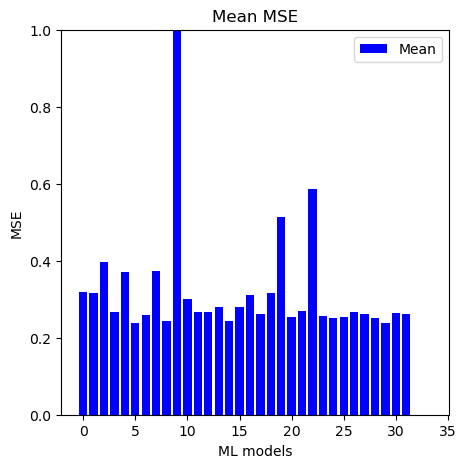

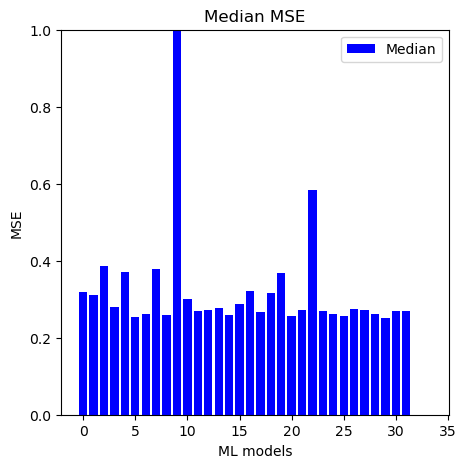

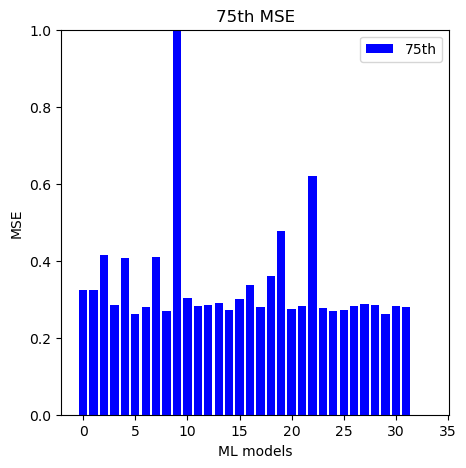

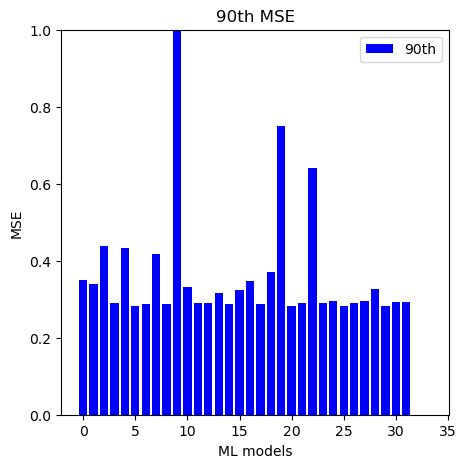

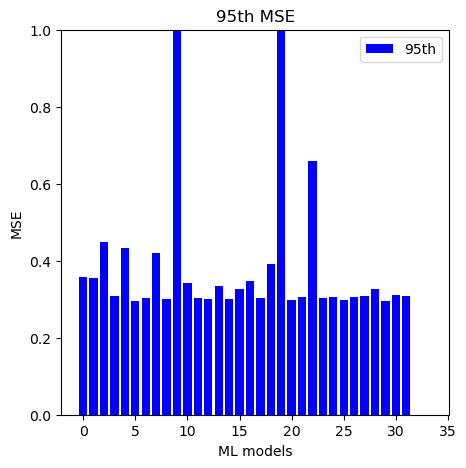

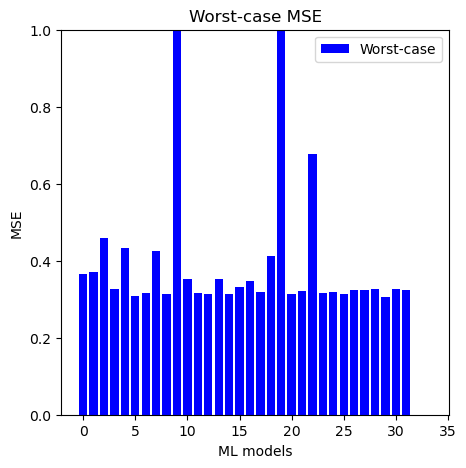

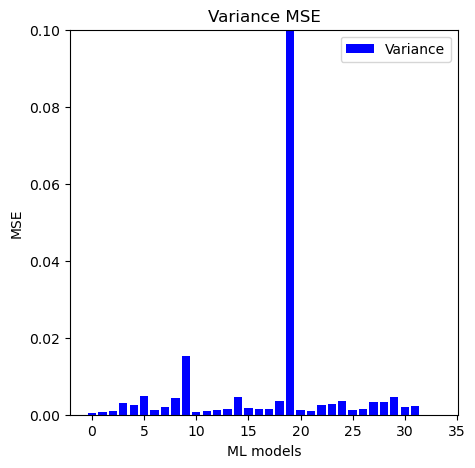

In [48]:
# display the statistica as bar plot

#plot the mean
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['mean'])), stats_mse_estimates['mean'], color='blue', label='Mean')
plt.title('Mean MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show() 

#plot the median
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['median'])), stats_mse_estimates['median'], color='blue', label='Median')
plt.title('Median MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show() 

#plot the 75th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['75th'])), stats_mse_estimates['75th'], color='blue', label='75th')
plt.title('75th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

#plot the 90th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['90th'])), stats_mse_estimates['90th'], color='blue', label='90th')
plt.title('90th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

#plot the 95th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['95th'])), stats_mse_estimates['95th'], color='blue', label='95th')
plt.title('95th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

# plot the worst-case
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['worst-case'])), stats_mse_estimates['worst-case'], color='blue', label='Worst-case')
plt.title('Worst-case MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()


# plot the variance
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['variance'])), stats_mse_estimates['variance'], color='blue', label='Variance')
plt.title('Variance MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0,0.1)
plt.legend()
plt.show()